# Muon analysis for CD4 T cells


In [1]:
# import libraries
import matplotlib
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib import pyplot as plt


KeyboardInterrupt



In [ ]:
# Set default parameters for plotting
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 100
matplotlib.rcParams["pdf.fonttype"] = 42

In [ ]:
# define working path
data_path = "/home/workspace/data/preRA_teaseq/EXP-00243/totalVI/"
fig_path = "/home/workspace/data/preRA_teaseq/EXP-00243/totalVI/figures/"
output_path = "/home/workspace/private/teaseq-analysis-v2-ide/preRA_teaseq/EXP-00243/totalVI/output_results/"
# define a project name
proj_name = "PreRA_TEASeq_CD4T_"

sc.settings.figdir = fig_path
sc.settings.autosave = False
sc.set_figure_params(vector_friendly=True, dpi_save=300)

In [ ]:
# set up color schemes
npg_color = [
    "#E64B35FF",
    "#4DBBD5FF",
    "#00A087FF",
    "#3C5488FF",
    "#F39B7FFF",
    "#8491B4FF",
    "#91D1C2FF",
    "#DC0000FF",
    "#7E6148FF",
    "#B09C85FF",
]
cluster_colors = [
    "#DC050C",
    "#FB8072",
    "#1965B0",
    "#7BAFDE",
    "#882E72",
    "#B17BA6",
    "#FF7F00",
    "#FDB462",
    "#E7298A",
    "#E78AC3",
    "#33A02C",
    "#B2DF8A",
    "#55A1B1",
    "#8DD3C7",
    "#A6761D",
    "#E6AB02",
    "#7570B3",
    "#BEAED4",
    "#666666",
    "#999999",
    "#aa8282",
    "#d4b7b7",
    "#8600bf",
    "#ba5ce3",
    "#808000",
    "#aeae5c",
    "#1e90ff",
    "#00bfff",
    "#56ff0d",
    "#ffff00",
]
ari_colors = ["#5AAA46", "#F59F00"]
cluster_colors_32 = [
    "#DC050C",
    "#F9786B",
    "#3668A8",
    "#68A0D5",
    "#844F8D",
    "#A36295",
    "#E07D40",
    "#FD9C35",
    "#F27075",
    "#E751A1",
    "#A7918D",
    "#57B247",
    "#9CD192",
    "#5EA9B4",
    "#8FCAB6",
    "#A8771C",
    "#E3A902",
    "#7F75A1",
    "#B2A3CE",
    "#79767E",
    "#8A8A8A",
    "#A38A8A",
    "#C2A0A0",
    "#AB58BB",
    "#9D29CF",
    "#A3698B",
    "#8E8E1D",
    "#88A686",
    "#1899FF",
    "#0BC7DF",
    "#60FF0C",
    "#FFFF00",
]


# load data


In [ ]:
# load the three modalities data with motif
cd4_mdata = mu.read('/home/workspace/data/preRA_teaseq/EXP-00243/totalVI/' + "PreRA_teaseq_cd4_3modality.h5mu")

In [27]:
cd4_mdata

MuData object with n_obs × n_vars = 44806 × 674626
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'cluster ratio', 'subject_id', 'Ethnicity', 'Race', 'Birth Year', 'Sex', 'cohort', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'ADT_snn_res.0.5', 'atac_cell_id', 'n_mito', 'n_fragments', 'peaks_frac', 'altius_frac', 'DoubletScore', 'DoubletEnrichment', 'Clusters', 'iterative_lsi_number_umap_dimension_1', 'iterative_lsi_number_umap_dimension_2', 'nCount_Tiles', 'nFeature_Tiles', 'nCount_cleanadt', 'nFeature_cleanadt', 'cleanadt_snn_res.0.5', 'Tiles_snn_res.0.8', 'SCT.weight', 'ADT.weight', 'Tiles.weight', 'wsnn_res.0.5', 'wsnn_res.0.8', 'l1_cell_types', 'l2_cell_types', 'clean_l2_cell_types', 'nCount_rna', 'nFeature_rna', 'immunehealth_l1', 'immunehealth_l1_conf_score', 'immunehealth_l2', 'immunehealth_l2_conf_score', 'immunehealth_l3', 'immunehealth_l3_conf_score', 'leiden_wnn', 'Archr_Clusters_0_8', 'leiden_wnn_1_2', 'atac_cluster'
  uns:	'Archr_Clusters_0_8_colors', 'clean_l2_cell_types_colors', 'cohort_colors', 'immunehealth_l3_colors', 'leiden', 'leiden_wnn_1_2_colors', 'leiden_wnn_colors', 'umap', 'wnn'
  obsm:	'X_umap'
  obsp:	'wnn_connectivities', 'wnn_distances'
  3 modalities
    rna:	44806 x 36601
      obs:	'log10umi', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_labels', 'conf_score', 'leiden_c3', 'Archr_Clusters_0_8', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1'
      var:	'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Archr_Clusters_0_8_colors', 'Archr_Clusters_0_8_wilcoxon', 'Archr_naive_wilcoxon', 'clean_l2_cell_types_colors', 'cohort_colors', 'dendrogram_Archr_Clusters_0_8', 'dendrogram_leiden', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'l2_cell_types_colors', 'leiden', 'leiden_colors', 'leiden_wilcoxon', 'leiden_wilcoxon_C10vsC0', 'log1p', 'neighbors', 'pca', 'rna:leiden_c3_colors', 'rna:leiden_colors', 'umap'
      obsm:	'X_NMFproj', 'X_pca', 'X_rnaumap', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    prot:	44806 x 166
      obs:	'atac_cluster', 'Archr_Clusters_0_8'
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'Archr_Clusters_0_8_wilcoxon_vari', 'clean_l2_cell_types_colors', 'dendrogram_atac_cluster', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'dsb'
      obsp:	'connectivities', 'distances'
    atac:	44806 x 637859
      obs:	'altius_count', 'altius_frac', 'barcodes', 'batch_id', 'BlacklistRatio', 'cell_name', 'chip_id', 'DoubletEnrichment', 'DoubletScore', 'gene_bodies_count', 'gene_bodies_frac', 'Gex_MitoRatio', 'Gex_nGenes', 'Gex_nUMI', 'Gex_RiboRatio', 'n_duplicate', 'n_fragments', 'n_mito', 'n_unique', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'original_barcodes', 'PassQC', 'pbmc_sample_id', 'peaks_count', 'peaks_frac', 'pool_id', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'singlet', 'tss_count', 'tss_frac', 'TSSEnrichment', 'well_id', 'Clusters', 'subject_id', 'coho

# rerun umap for each modality


## process rna


In [ ]:
rna = cd4_mdata["rna"]

In [ ]:
# redo the normalization
rna.X = rna.layers["counts"].copy()
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)

In [ ]:
# double check the counts slot
# rna.layers['counts'][1:25, 1:25].toarray()

In [ ]:
# # save log-normalised counts in a .raw slot:
rna.raw = rna
# # scale
sc.pp.scale(rna, max_value=10)

In [ ]:
p1 = sns.histplot(rna.obs["total_counts"], bins=100, kde=False)

In [ ]:
rna

In [ ]:
# %%time
sc.pp.highly_variable_genes(rna, min_mean=0.0125, max_mean=3, min_disp=0.5)

In [ ]:
sc.pl.highly_variable_genes(rna)

In [ ]:
# redo the PCA
sc.tl.pca(rna, svd_solver="arpack")
sc.pl.pca_variance_ratio(rna, log=True)

In [ ]:
sc.pp.neighbors(rna)
sc.tl.umap(rna)

In [ ]:
# run cluters and umap
sc.tl.leiden(rna, resolution=1)

In [ ]:
sc.tl.leiden(rna, resolution=0.5, restrict_to=["leiden", ["3"]], key_added="leiden_c3")

In [ ]:
cd4_mdata.update()

In [ ]:
cd4_mdata

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="rna:X_umap",
    legend_fontsize=6,
    color=["clean_l2_cell_types", "immunehealth_l3"],
    save=proj_name + "cd4_rnaumap.pdf",
)

In [ ]:
# plot the umap
mu.pl.embedding(cd4_mdata, basis="rna:X_umap", color=["immunehealth_l3"])

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata, basis="rna:X_umap", color=["rna:leiden_c3"], legend_loc="on data"
)

## process ADT


In [6]:
# redo the nromalization
adt = cd4_mdata["prot"]
adt

AnnData object with n_obs × n_vars = 44806 × 166
    obs: 'atac_cluster', 'Archr_Clusters_0_8'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Archr_Clusters_0_8_wilcoxon_vari', 'clean_l2_cell_types_colors', 'dendrogram_atac_cluster', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'dsb'
    obsp: 'connectivities', 'distances'

In [10]:
# all the isotype controls were set as not variable
adt.var[~adt.var["highly_variable"]]

,highly_variable,means,dispersions,dispersions_norm
Rat_IgG2b_k_Isotype_Ctrl,False,71.423968,82.819989,-0.707107
Rat_IgG1_l_Isotype_Ctrl,False,15.911684,26.632438,-0.385157
Rat_IgG2a_k_Isotype_Ctrl,False,18.389003,28.306037,0.583965
Rat_IgG2c_k_Isotype_Ctrl,False,44.876668,56.261725,1.310615
Armenian_Hamster_IgG_Isotype_Ctrl,False,14.475154,25.213524,0.729535


In [11]:
# remove isotype in the adt analysis
adt = adt[:, adt.var[adt.var["highly_variable"]].index].copy()

In [12]:
cd4_mdata.update()

/home/workspace/environment/py_scrna/lib/python3.12/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/py_scrna/lib/python3.12/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [ ]:
# run pca
sc.tl.pca(adt)
sc.pl.pca_variance_ratio(adt, log=True)

In [ ]:
# clustering umap in protein
sc.pp.neighbors(adt)
sc.tl.umap(adt)

In [ ]:
cd4_mdata.update()

In [ ]:
cd4_mdata

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="prot:X_umap",
    color=["clean_l2_cell_types", "immunehealth_l2", "immunehealth_l3"],
    save=proj_name + "cd4_adtumap.png",
    legend_loc="on data",
)

## process atac


In [38]:
# redo the nromalization
atac = cd4_mdata["atac"]
atac

AnnData object with n_obs × n_vars = 44806 × 637859
    obs: 'altius_count', 'altius_frac', 'barcodes', 'batch_id', 'BlacklistRatio', 'cell_name', 'chip_id', 'DoubletEnrichment', 'DoubletScore', 'gene_bodies_count', 'gene_bodies_frac', 'Gex_MitoRatio', 'Gex_nGenes', 'Gex_nUMI', 'Gex_RiboRatio', 'n_duplicate', 'n_fragments', 'n_mito', 'n_unique', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'original_barcodes', 'PassQC', 'pbmc_sample_id', 'peaks_count', 'peaks_frac', 'pool_id', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'singlet', 'tss_count', 'tss_frac', 'TSSEnrichment', 'well_id', 'Clusters', 'subject_id', 'cohort', 'Birth.Year', 'Sex', 'wsnn_res.0.5', 'l1_cell_types', 'l2_cell_types', 'clean_l2_cell_types', 'ReadsInPeaks', 'FRIP', 'MochaPeak_clusters_1', 'n_genes_by_counts', 'total_counts', 'leiden'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'Archr_Clusters_0_8_colors', 'X_name', 'a

In [ ]:
sc.pp.neighbors(atac, use_rep="X_LSI")
sc.tl.umap(atac)

In [ ]:
# run cluters and umap
sc.tl.leiden(atac, resolution=0.8)

In [ ]:
cd4_mdata.update()

In [ ]:
atac

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    color=["clean_l2_cell_types", "immunehealth_l2", "immunehealth_l3", "atac:leiden"],
    save=proj_name + "cd4_ArchRumap.png",
    legend_loc="on data",
)

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    color=["clean_l2_cell_types"],
    save=proj_name + "cd4_ArchRumap_clean_l2_cell_types.png",
)

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    color=["Clusters"],
    save=proj_name + "cd4_ArchRumap_Clusters.png",
)

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    color=["clean_l2_cell_types", "immunehealth_l3", "cohort", "atac:leiden"],
    legend_loc="on data",
)

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata, basis="atac:X_ArchRumap", color=["cohort"], legend_loc="on data"
)

In [ ]:
# plot the umap
mu.pl.embedding(cd4_mdata, basis="atac:X_ArchRumap", color=["immunehealth_l3"])

## run 3wnn


In [13]:
cd4_mdata

MuData object with n_obs × n_vars = 44806 × 674626
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'cluster ratio', 'subject_id', 'Ethnicity', 'Race', 'Birth Year', 'Sex', 'cohort', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'ADT_snn_res.0.5', 'atac_cell_id', 'n_mito', 'n_fragments', 'peaks_frac', 'altius_frac', 'DoubletScore', 'DoubletEnrichment', 'Clusters', 'iterative_lsi_number_umap_dimension_1', 'iterative_lsi_number_umap_dimension_2', 'nCount_Tiles', 'nFeature_Tiles', 'nCount_cleanadt', 'nFeature_cleanadt', 'cleanadt_snn_res.0.5', 'Tiles_snn_res.0.8', 'SCT.weight', 'ADT.weight', 'Tiles.weight', 'wsnn_res.0.5', 'wsnn_res.0.8', 'l1_cell_types', 'l2_cell_types', 'clean_l2_cell_types', 'nCount_rna', 'nFeature_rna', 'immunehealth_l1', 'immunehealth_l1_conf_score', 'immunehealth_l2', 'immunehealth_l2_conf_score', 'immunehealth_l3', 'immunehealth_l3_conf_score', 'leiden_wnn', 'Archr_Clusters_0_8', 'leiden_wnn_1_2', 'atac_cluster'
  uns:	'Archr_Clusters_0_8_colors', 'clean_l2_cell_types_colors', 'cohort_colors', 'immunehealth_l3_colors', 'leiden', 'leiden_wnn_1_2_colors', 'leiden_wnn_colors', 'umap', 'wnn'
  obsm:	'X_umap'
  obsp:	'wnn_connectivities', 'wnn_distances'
  3 modalities
    rna:	44806 x 36601
      obs:	'log10umi', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_labels', 'conf_score', 'leiden_c3', 'Archr_Clusters_0_8', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1'
      var:	'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Archr_Clusters_0_8_colors', 'Archr_Clusters_0_8_wilcoxon', 'Archr_naive_wilcoxon', 'clean_l2_cell_types_colors', 'cohort_colors', 'dendrogram_Archr_Clusters_0_8', 'dendrogram_leiden', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'l2_cell_types_colors', 'leiden', 'leiden_colors', 'leiden_wilcoxon', 'leiden_wilcoxon_C10vsC0', 'log1p', 'neighbors', 'pca', 'rna:leiden_c3_colors', 'rna:leiden_colors', 'umap'
      obsm:	'X_NMFproj', 'X_pca', 'X_rnaumap', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    prot:	44806 x 166
      obs:	'atac_cluster', 'Archr_Clusters_0_8'
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'Archr_Clusters_0_8_wilcoxon_vari', 'clean_l2_cell_types_colors', 'dendrogram_atac_cluster', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'dsb'
      obsp:	'connectivities', 'distances'
    atac:	44806 x 637859
      obs:	'altius_count', 'altius_frac', 'barcodes', 'batch_id', 'BlacklistRatio', 'cell_name', 'chip_id', 'DoubletEnrichment', 'DoubletScore', 'gene_bodies_count', 'gene_bodies_frac', 'Gex_MitoRatio', 'Gex_nGenes', 'Gex_nUMI', 'Gex_RiboRatio', 'n_duplicate', 'n_fragments', 'n_mito', 'n_unique', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'original_barcodes', 'PassQC', 'pbmc_sample_id', 'peaks_count', 'peaks_frac', 'pool_id', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'singlet', 'tss_count', 'tss_frac', 'TSSEnrichment', 'well_id', 'Clusters', 'subject_id', 'coho

In [ ]:
mu.pp.neighbors(cd4_mdata, key_added="wnn")

In [ ]:
mu.tl.umap(cd4_mdata, neighbors_key="wnn", random_state=10)

In [ ]:
sc.tl.leiden(cd4_mdata, resolution=0.8, neighbors_key="wnn", key_added="leiden_wnn_0.8")

In [ ]:
mu.pl.umap(
    cd4_mdata,
    color=["rna:mod_weight", "prot:mod_weight", "atac:mod_weight"],
    cmap="RdBu",
)

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    color=["clean_l2_cell_types"],
    legend_loc="none",
    save=proj_name + "clean_l2_cell_types_Archr_umap.pdf",
)

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="rna:X_umap",
    title="rna_umap",
    legend_loc=None,
    color=["immunehealth_l3"],
    save=proj_name + "immunehealth_l3_rnaumap.png",
)

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="prot:X_umap",
    title="adt_umap",
    legend_loc=None,
    color=["immunehealth_l3"],
    save=proj_name + "immunehealth_l3_adtUmap.png",
)

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    title="ATAC_umap",
    legend_loc=None,
    color=["immunehealth_l3"],
    save=proj_name + "immunehealth_l3_ATACUmap.png",
)

In [ ]:
mu.pl.umap(
    cd4_mdata,
    color=["immunehealth_l2"],
    # palette=cluster_colors,
    save=proj_name + "immunehealth_l2_3wnn_umap.pdf",
)

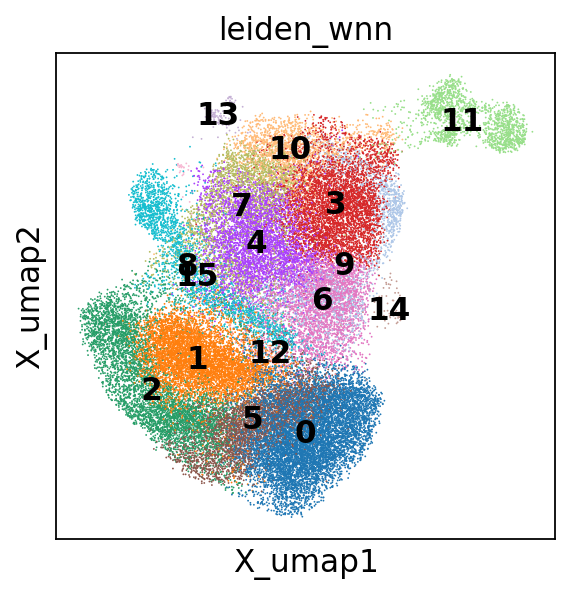

In [28]:
mu.pl.umap(
    cd4_mdata,
    color=["leiden_wnn"],
    legend_loc="on data",
    # palette=cluster_colors,
    save=proj_name + "leiden_3wnn_umap.pdf",
)

### label cd4 t cells by 3wnn clusters


In [31]:
# label based on the wnn clusters
cd4_mdata.obs["3wnn_labels"] = cd4_mdata.obs["leiden_wnn"].astype("int")
cd4_mdata.obs.loc[
    cd4_mdata.obs["3wnn_labels"].isin([0, 1, 2, 5, 12]), "3wnn_labels"
] = "CD4 Naive"
cd4_mdata.obs.loc[cd4_mdata.obs["3wnn_labels"].isin([8, 15]), "3wnn_labels"] = "Treg"
cd4_mdata.obs.loc[cd4_mdata.obs["3wnn_labels"].isin([11]), "3wnn_labels"] = "CD4 CTL"
cd4_mdata.obs.loc[
    cd4_mdata.obs["3wnn_labels"].isin([3, 6, 9, 10, 14, 4, 7, 13]), "3wnn_labels"
] = "CD4 Memory"
cd4_mdata.obs["3wnn_labels"] = cd4_mdata.obs["3wnn_labels"].astype("str")

/tmp/ipykernel_1643/2826575187.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'CD4 Naive' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cd4_mdata.obs.loc[


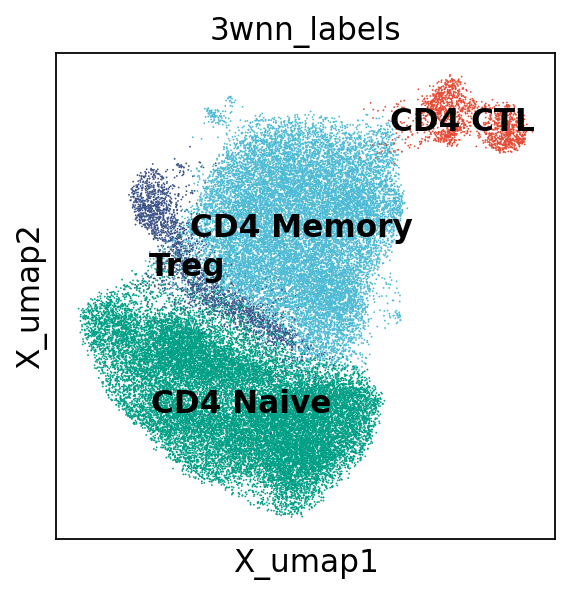

In [32]:
mu.pl.umap(
    cd4_mdata,
    color=["3wnn_labels"],
    legend_loc="on data",
    palette=npg_color,
    save=proj_name + "3wnn_labels_types_3wnn_umap.pdf",
)

In [33]:
cd4_mdata.obs["status"] = cd4_mdata.obs["cohort"].astype("str")
cd4_mdata.obs.loc[cd4_mdata.obs["status"] == "Healthy", "status"] = "CON2"
cd4_mdata.obs.loc[cd4_mdata.obs["status"] == "pre-RA", "status"] = "ARI"

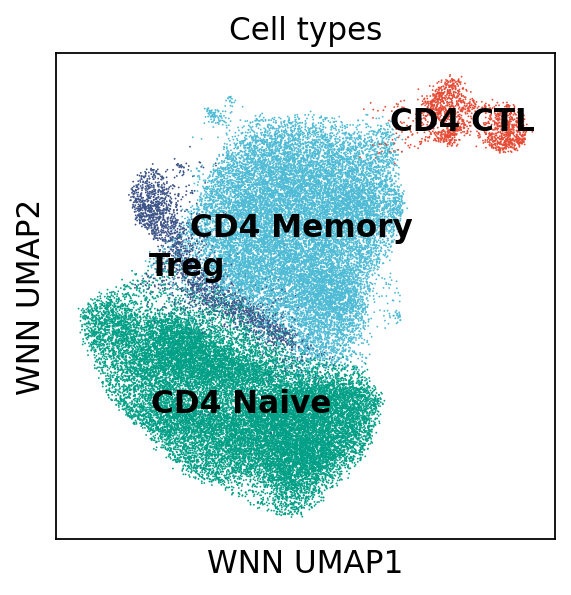

In [34]:
p1 = mu.pl.umap(
    cd4_mdata,
    color=["3wnn_labels"],
    legend_loc="on data",
    palette=npg_color,
    show=False,
)
p1.set_xlabel("WNN UMAP1")
p1.set_ylabel("WNN UMAP2")
p1.set_title("Cell types")
p1.figure.savefig(fig_path + proj_name + "3wnn_labels_3wnn_umap.pdf")

In [35]:
cd4_mdata

MuData object with n_obs × n_vars = 44806 × 674626
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'barcodes', 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'rna_cell_uuid', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'nCount_ADT', 'nFeature_ADT', 'percent.mt', 'cluster ratio', 'subject_id', 'Ethnicity', 'Race', 'Birth Year', 'Sex', 'cohort', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l3.score', 'predicted.celltype.l3', 'ADT_snn_res.0.5', 'atac_cell_id', 'n_mito', 'n_fragments', 'peaks_frac', 'altius_frac', 'DoubletScore', 'DoubletEnrichment', 'Clusters', 'iterative_lsi_number_umap_dimension_1', 'iterative_lsi_number_umap_dimension_2', 'nCount_Tiles', 'nFeature_Tiles', 'nCount_cleanadt', 'nFeature_cleanadt', 'cleanadt_snn_res.0.5', 'Tiles_snn_res.0.8', 'SCT.weight', 'ADT.weight', 'Tiles.weight', 'wsnn_res.0.5', 'wsnn_res.0.8', 'l1_cell_types', 'l2_cell_types', 'clean_l2_cell_types', 'nCount_rna', 'nFeature_rna', 'immunehealth_l1', 'immunehealth_l1_conf_score', 'immunehealth_l2', 'immunehealth_l2_conf_score', 'immunehealth_l3', 'immunehealth_l3_conf_score', 'leiden_wnn', 'Archr_Clusters_0_8', 'leiden_wnn_1_2', 'atac_cluster', '3wnn_labels', 'status'
  uns:	'Archr_Clusters_0_8_colors', 'clean_l2_cell_types_colors', 'cohort_colors', 'immunehealth_l3_colors', 'leiden', 'leiden_wnn_1_2_colors', 'leiden_wnn_colors', 'umap', 'wnn', '3wnn_labels_colors'
  obsm:	'X_umap'
  obsp:	'wnn_connectivities', 'wnn_distances'
  3 modalities
    rna:	44806 x 36601
      obs:	'log10umi', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'predicted_labels', 'conf_score', 'leiden_c3', 'Archr_Clusters_0_8', 'NMF0_Cytotoxic', 'NMF1_Treg', 'NMF2_Th17', 'NMF3_Naive', 'NMF4_Act', 'NMF5_Th2', 'NMF6_Tfh', 'NMF7_IFN', 'NMF8_Cent_Mem', 'NMF9_Thymic_Emi', 'NMF10_Tissue', 'NMF11_Th1'
      var:	'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Archr_Clusters_0_8_colors', 'Archr_Clusters_0_8_wilcoxon', 'Archr_naive_wilcoxon', 'clean_l2_cell_types_colors', 'cohort_colors', 'dendrogram_Archr_Clusters_0_8', 'dendrogram_leiden', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'l2_cell_types_colors', 'leiden', 'leiden_colors', 'leiden_wilcoxon', 'leiden_wilcoxon_C10vsC0', 'log1p', 'neighbors', 'pca', 'rna:leiden_c3_colors', 'rna:leiden_colors', 'umap'
      obsm:	'X_NMFproj', 'X_pca', 'X_rnaumap', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    prot:	44806 x 166
      obs:	'atac_cluster', 'Archr_Clusters_0_8'
      var:	'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'Archr_Clusters_0_8_wilcoxon_vari', 'clean_l2_cell_types_colors', 'dendrogram_atac_cluster', 'hvg', 'immunehealth_l1_colors', 'immunehealth_l2_colors', 'immunehealth_l3_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts', 'dsb'
      obsp:	'connectivities', 'distances'
    atac:	44806 x 637859
      obs:	'altius_count', 'altius_frac', 'barcodes', 'batch_id', 'BlacklistRatio', 'cell_name', 'chip_id', 'DoubletEnrichment', 'DoubletScore', 'gene_bodies_count', 'gene_bodies_frac', 'Gex_MitoRatio', 'Gex_nGenes', 'Gex_nUMI', 'Gex_RiboRatio', 'n_duplicate', 'n_fragments', 'n_mito', 'n_unique', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'original_barcodes', 'PassQC', 'pbmc_sample_id', 'peaks_count', 'peaks_frac', 'pool_id', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'singlet', 'tss_count', 'tss_frac', 'TSSEnrichme

In [39]:
atac.obsm["X_archrumap"] = atac.obsm["X_ArchRumap"]
atac.obs["status"] = cd4_mdata.obs["status"]

In [40]:
sc.tl.embedding_density(atac, basis="ArchRumap", groupby="status")

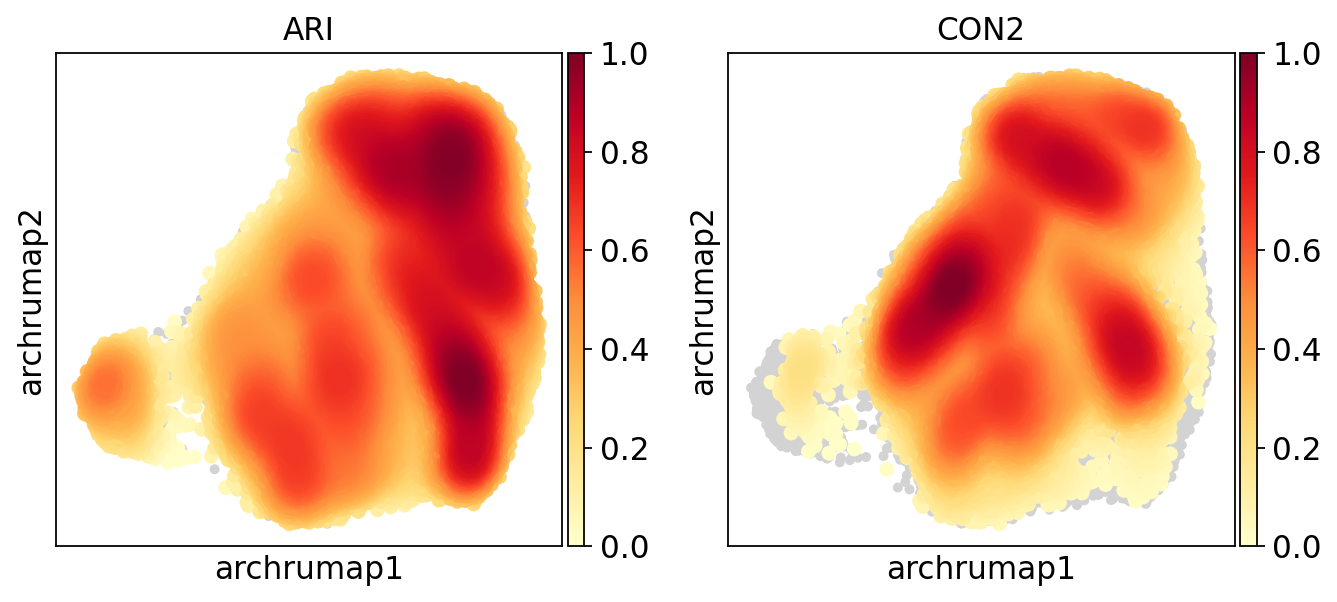

In [41]:
sc.pl.embedding_density(
    atac,
    basis="archrumap",
    key="archrumap_density_status",
    save=proj_name + "archrumap_status_density.pdf",
)

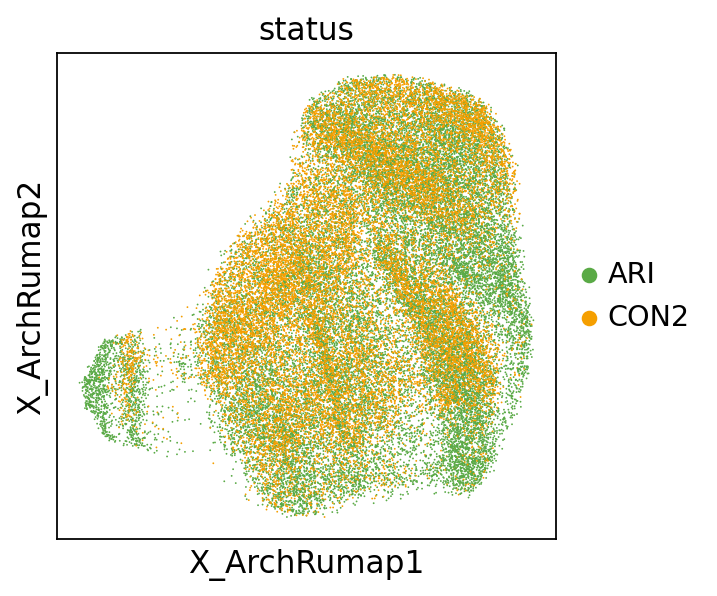

In [42]:
# plot the umap
mu.pl.embedding(
    cd4_mdata, basis="atac:X_ArchRumap", palette=ari_colors, color=["status"]
)

## analyze ArchR ATAC clusters


In [44]:
rna = cd4_mdata["rna"]
adt = cd4_mdata["prot"]

In [ ]:
# load cluster identity in archr and load in mudata
archr_cluster = pd.read_csv(
    "/home/workspace/data/preRA_teaseq/output_results/cd4_t/atac/PreRA_teaseq_cd4_t_atac_Clusters_0.8_cluster_barcodes.csv",
    index_col=0,
)
archr_cluster

In [ ]:
cd4_mdata.obs = cd4_mdata.obs.merge(
    archr_cluster, how="left", left_index=True, right_index=True
)

In [ ]:
cd4_mdata

In [45]:
cd4_mdata.obs["atac_cluster"] = (
    cd4_mdata.obs["Archr_Clusters_0_8"].str.replace("C", "T").copy()
)

## plot fig 6A

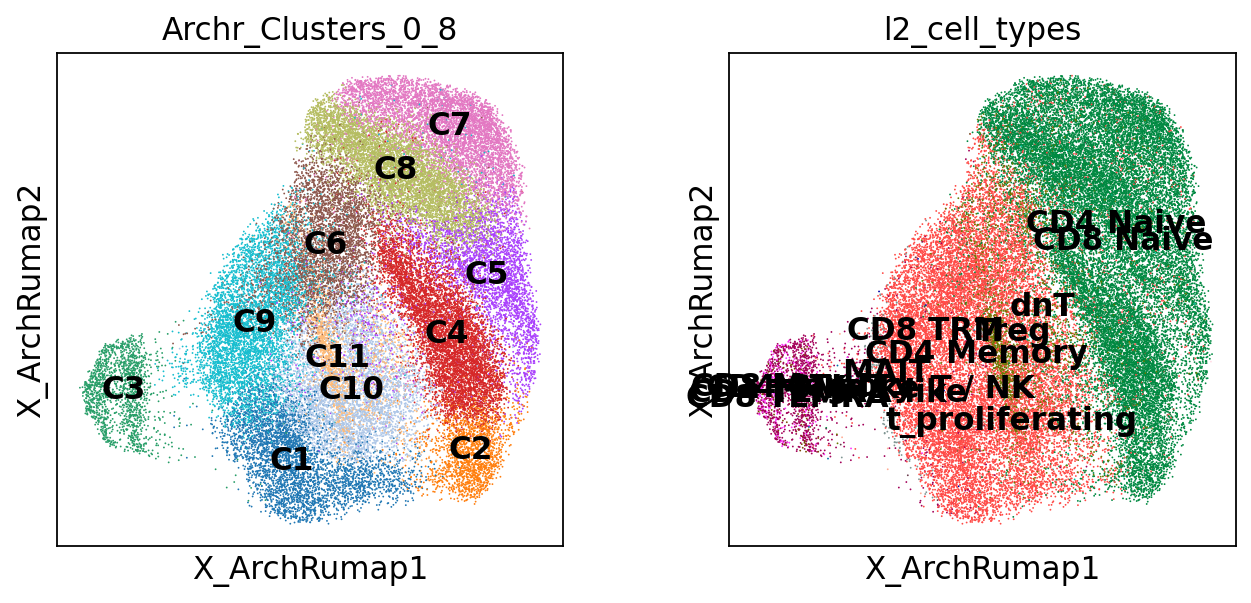

In [46]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    save=proj_name + "cohort_umap.png",
    color=["Archr_Clusters_0_8", "l2_cell_types"],
    legend_loc="on data",
)

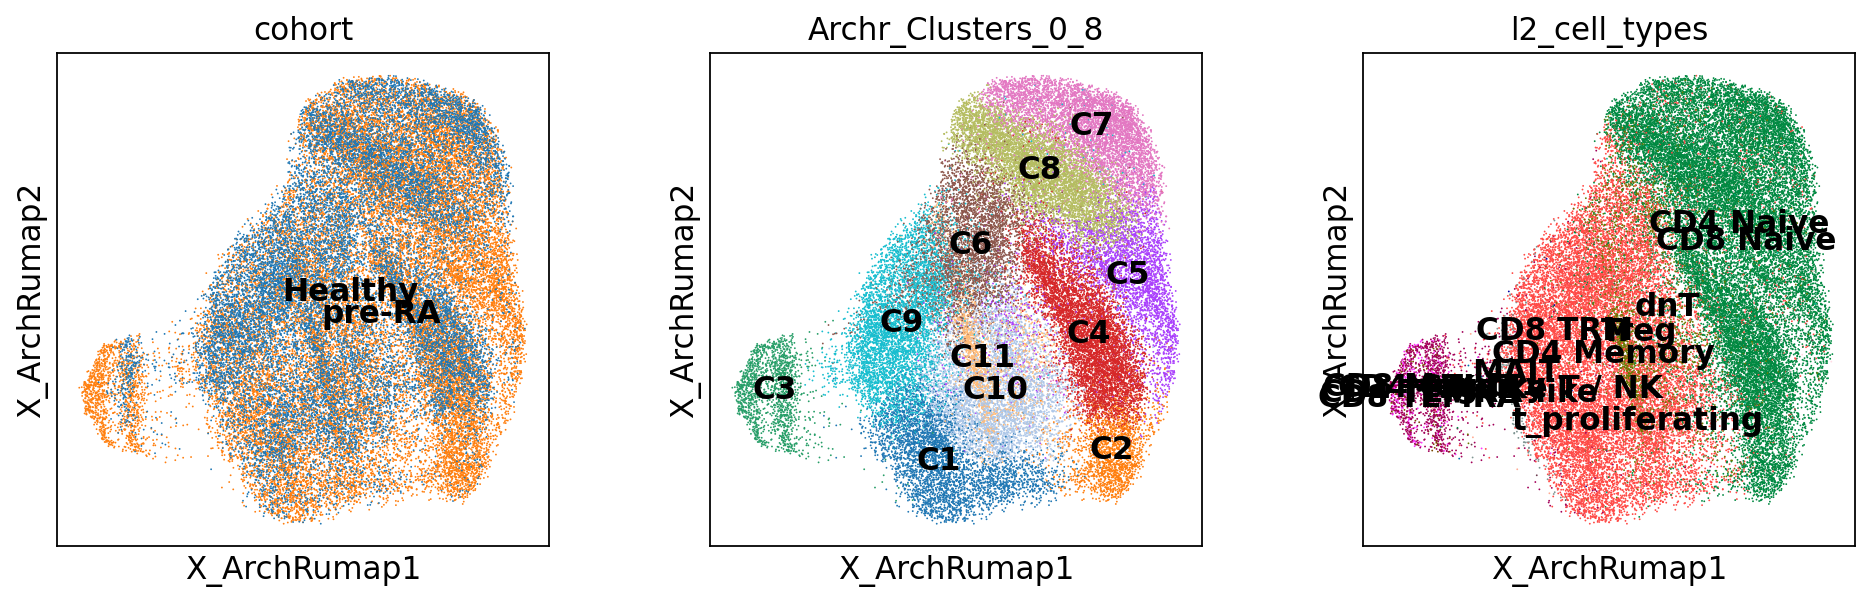

In [47]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    save=proj_name + "cohort_umap.png",
    color=["cohort", "Archr_Clusters_0_8", "l2_cell_types"],
    legend_loc="on data",
)

In [48]:
tcluster_colors = [
    "#8B97A7",
    "#9E5780",
    "#E79CA3",
    "#542654",
    "#8cd4b7",
    "#AB9736",
    "#28594d",
    "#B34205",
    "#1a7585",
    "#e9616d",
    "#85d2ff",
    "#0f2a43",
]

In [49]:
cd4_mdata.obs["atac_cluster"] = (
    cd4_mdata.obs["Archr_Clusters_0_8"].str.replace("C", "").copy()
)
# cd4_mdata.obs.loc[cd4_mdata.obs['3wnn_labels'].isin(['C2', 'C0','C0','C0',]), '3wnn_labels'] = 'CD4 Naive'
# cd4_mdata.obs.loc[cd4_mdata.obs['3wnn_labels'].isin([8, 15]), '3wnn_labels'] = 'Treg'
# cd4_mdata.obs.loc[cd4_mdata.obs['3wnn_labels'].isin([11]), '3wnn_labels'] = 'CD4 CTL'
# cd4_mdata.obs.loc[cd4_mdata.obs['3wnn_labels'].isin([3, 6, 9,10, 14, 4, 7, 13]), '3wnn_labels'] = 'CD4 Memory'
# cd4_mdata.obs['3wnn_labels'] = cd4_mdata.obs['3wnn_labels'].astype('str')

In [50]:
cd4_mdata.obs["atac_cluster"].unique()

array(['4', '6', '7', '3', '9', '8', '1', '10', '5', '11', '2'],
      dtype=object)

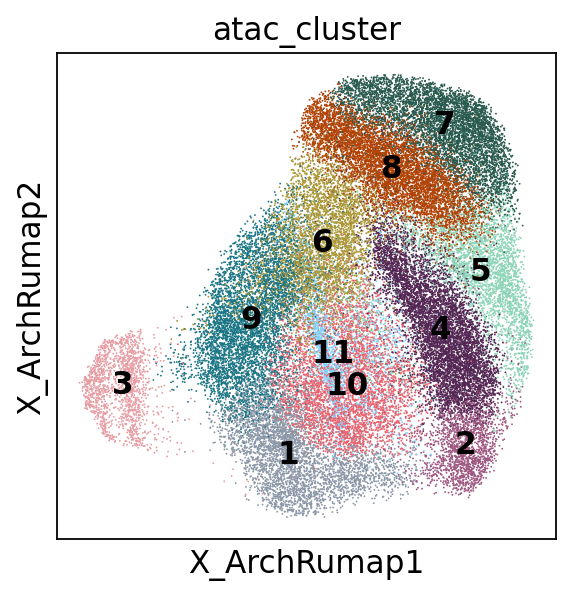

In [51]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    palette=tcluster_colors,
    save=proj_name + "atac_cluster_umap.pdf",
    color=["atac_cluster"],
    legend_loc="on data",
)

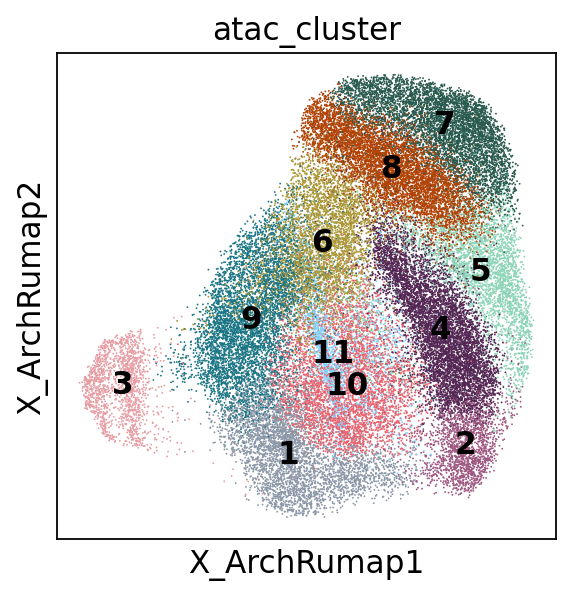

In [52]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    palette=tcluster_colors,
    save=proj_name + "atac_cluster_umap.pdf",
    color=["atac_cluster"],
    legend_loc="on data",
)

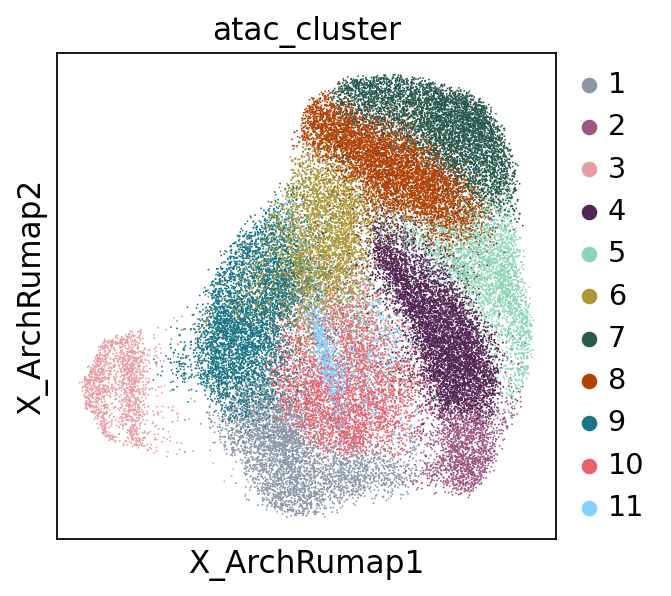

In [53]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    palette=tcluster_colors,
    save=proj_name + "atac_cluster_legend.pdf",
    color=["atac_cluster"],
)

## plot Fig S12B

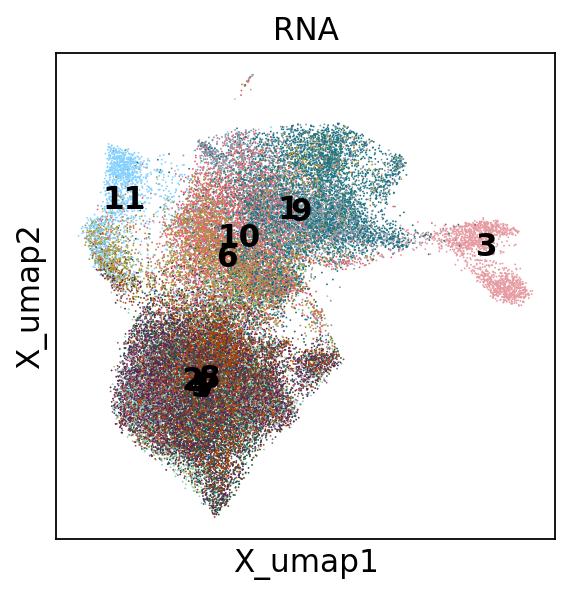

In [59]:
# plot the umap
mu.pl.embedding(
    cd4_mdata, basis="rna:X_umap", palette=tcluster_colors, color=["atac_cluster"],
    legend_loc="on data",
    title="RNA",
    save=proj_name + "atac_cluster_rna_umap.pdf"
)

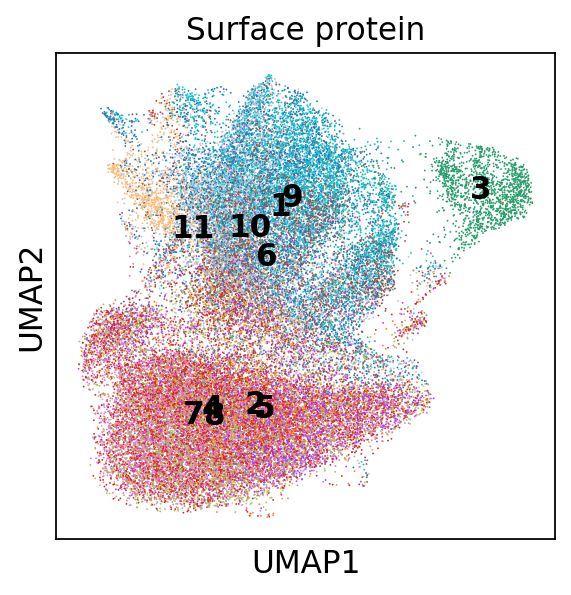

In [60]:
# plot umap in all modaliry
adt.obs["atac_cluster"] = cd4_mdata.obs["atac_cluster"].copy()
mu.pl.umap(
    adt,
    color=["atac_cluster"],
    legend_loc="on data",
    title="Surface protein",
    save=proj_name + "atac_cluster_adt_umap.pdf",
)

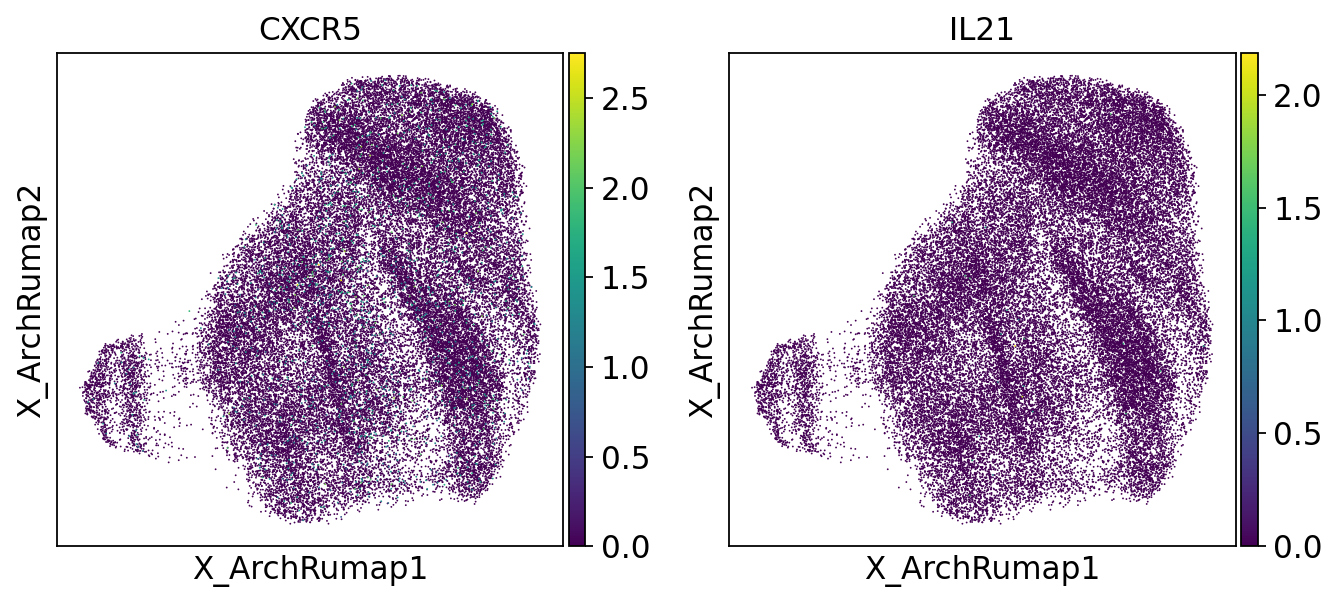

In [61]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    color=["rna:CXCR5", "rna:IL21"],
    ncols=2,  # vmin ='p1', vmax ='p99',
    save=proj_name + "_Archr_Clusters_0_8_umap_tfh_genes.pdf",
    legend_loc="on data",
)

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    color=[
        "prot:CD25",
        "prot:CD45RA",
        "prot:CD45RO",
        "prot:CD185",
        "prot:CD279",
        "prot:CD62L",
        "rna:CXCR5",
        "rna:GZMB",
        "rna:IL21",
        "rna:PDCD1",
        "rna:SELL",
        "rna:CCR7",
        "rna:SELPLG",
        "Archr_Clusters_0_8",
    ],
    ncols=4,
    vmin="p1",
    vmax="p99",
    save=proj_name + "rna_Archr_Clusters_0_8_umap.png",
    legend_loc="on data",
)

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    color=markers,
    vmin="p1",
    vmax="p99",
    ncols=2,
    save=proj_name + "Archr_Clusters_0_8_protein_cd62l_CD162_umap.png",
    legend_loc="on data",
)

In [ ]:
# plot the umap
mu.pl.embedding(
    cd4_mdata,
    basis="atac:X_ArchRumap",
    color=[
        "prot:CD62L",
        "prot:CD162",
        "rna:SELL",
        "rna:SELPLG",
    ],  # vmin ='p1', vmax ='p99',
    ncols=2,
    save=proj_name + "Archr_Clusters_0_8_rna_protein_cd62l_CD162_umap.png",
)

In [62]:
cd4_mdata.update()

/home/workspace/environment/py_scrna/lib/python3.12/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/py_scrna/lib/python3.12/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## test for marker DEGs in atac clusters

In [86]:
# test for marker genes in atac clusters
# use rna
rna = cd4_mdata["rna"]
rna.obs["atac_cluster"] = cd4_mdata.obs["atac_cluster"].copy()

In [87]:
rna.obs["atac_cluster"] = rna.obs["atac_cluster"].astype("str")

In [88]:
# test on degs
sc.tl.rank_genes_groups(
    rna,
    groupby="atac_cluster",
    method="wilcoxon",
    key_added="atac_cluster_wilcoxon",
)

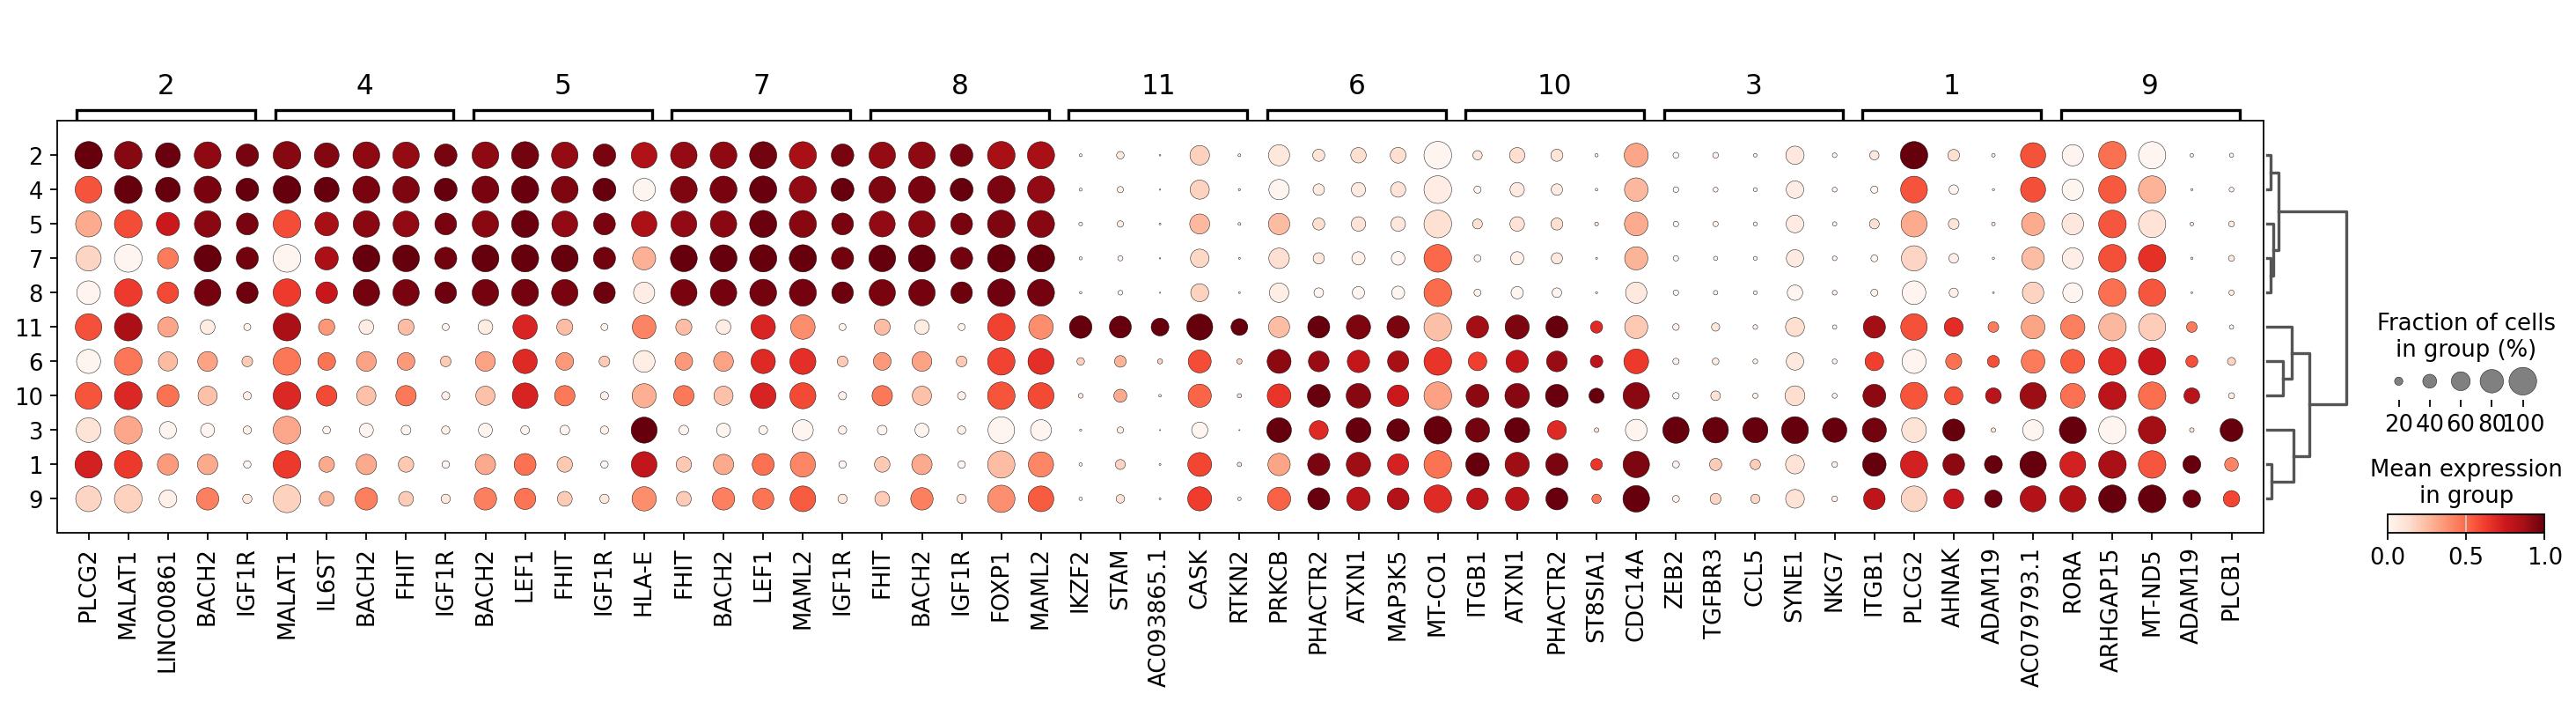

In [89]:
cluster_name = "atac_cluster"
sc.pl.rank_genes_groups_dotplot(
    rna,
    groupby='atac_cluster',
    standard_scale="var",
    n_genes=5,
    key='atac_cluster_wilcoxon',
    save="_" + proj_name + cluster_name + "_top_deg_dotplot_scale.png",
)

## test for marker ADTs in atac clusters

In [90]:
# test on adts
adt = cd4_mdata["prot"]
adt.obs["atac_cluster"] = cd4_mdata.obs["atac_cluster"].copy()

In [96]:
# run daps in all adts except the isotypes
sc.tl.rank_genes_groups(
    adt,
    groupby="atac_cluster",
    method="wilcoxon",
    key_added="atac_cluster_wilcoxon",
)

/home/workspace/environment/py_scrna/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/workspace/environment/py_scrna/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/workspace/environment/py_scrna/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/workspace/environment/py_scrna/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/workspace/environment/py_scrna/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  se

In [97]:
adt.obs["atac_cluster"]

bd196bb4867611ec8396aea599a86ab5     4
bd19abb0867611ec8396aea599a86ab5     6
bd19c73a867611ec8396aea599a86ab5     7
bd19ceba867611ec8396aea599a86ab5     3
bd1eff66867611ec8396aea599a86ab5     7
                                    ..
6979e346867911ecb648ee55e4236e76    10
697e34be867911ecb648ee55e4236e76     8
6982914e867911ecb648ee55e4236e76    10
6991199e867911ecb648ee55e4236e76     6
69963c12867911ecb648ee55e4236e76    11
Name: atac_cluster, Length: 44806, dtype: category
Categories (11, object): ['1', '2', '3', '4', ..., '8', '9', '10', '11']

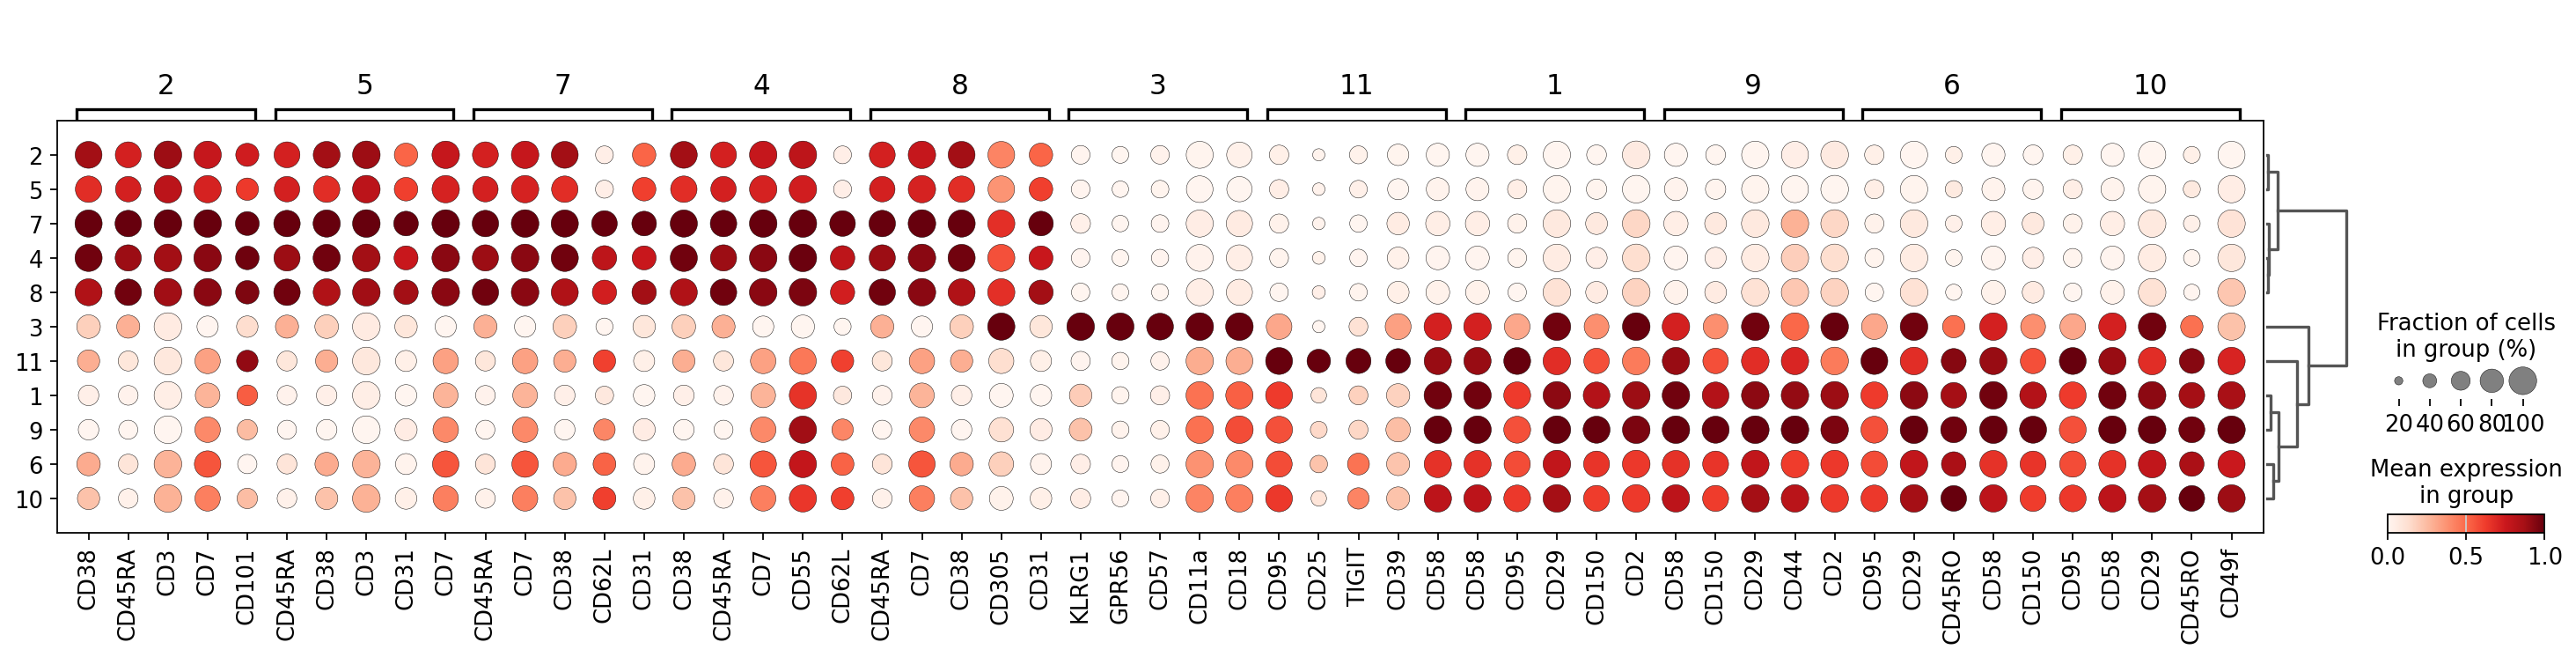

In [99]:
cluster_name = "atac_cluster"
sc.tl.dendrogram(adt, groupby=cluster_name)
sc.pl.rank_genes_groups_dotplot(
    adt,
    groupby=cluster_name,
    standard_scale="var",
    n_genes=5,
    key="atac_cluster_wilcoxon",
    save="_" + proj_name + cluster_name + "_adt_dotplot_scale.pdf",
)

### plot Fig 6C

In [106]:
# output the deg list
cluster_name = "atac_cluster"
leiden_deg = sc.get.rank_genes_groups_df(
    adt, key="atac_cluster_wilcoxon", pval_cutoff=None, group=None
).rename({"group": cluster_name}, axis="columns")
leiden_deg["direction"] = np.where(leiden_deg["logfoldchanges"] > 0, "up", "down")
leiden_deg = leiden_deg.reindex(
    leiden_deg["scores"].abs().sort_values(ascending=False).index
)
markers = ["CD62L", "CD162", "CD45RO", "CD45RA", "CD25", "KLRG1", "CD49d", "CD95"]

# output deg results for CD162 and CD62L
C2_c5_deps= leiden_deg.loc[(leiden_deg['names'].isin(["CD62L", "CD162"])) & (leiden_deg['atac_cluster'].isin(['2', '5']))]
C2_c5_deps.to_csv(output_path + proj_name + cluster_name+'c2c5_wilcoxon_deps.csv')


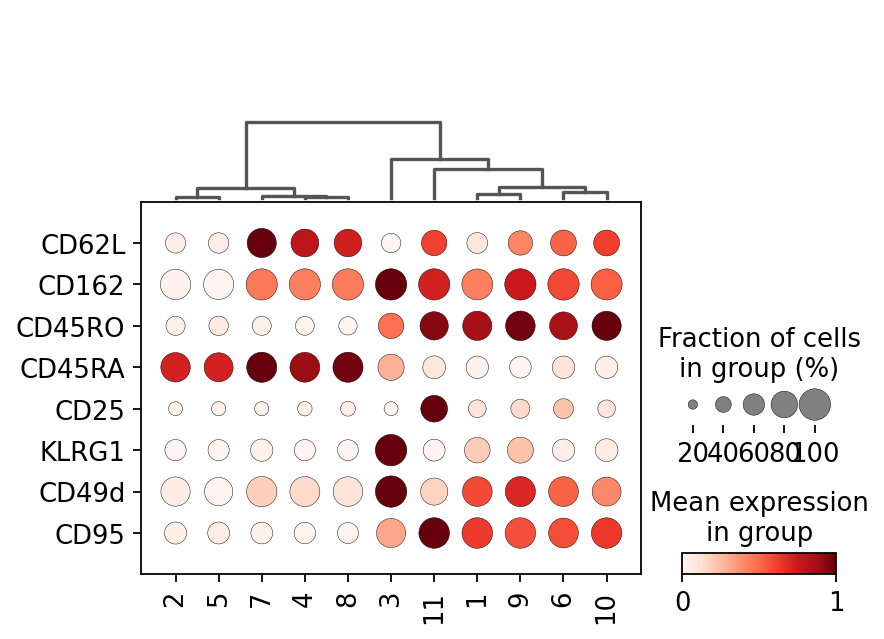

In [100]:
# plot the dotplot to differentiate the clusters
markers = ["CD62L", "CD162", "CD45RO", "CD45RA", "CD25", "KLRG1", "CD49d", "CD95"]

p1 = sc.pl.dotplot(
    adt,
    markers,
    groupby="atac_cluster",
    swap_axes=True,
    standard_scale="var",
    dendrogram=True,
    save=proj_name + "atac_cluster_dotplot.pdf",
)

In [101]:
# Get expression matrix for markers and group info
group_col = "atac_cluster"
df = sc.get.obs_df(adt, keys=markers + [group_col])


# Calculate % expressing cells per marker per group
def percent_expressing(x):
    return np.mean(x > 0) * 100

agg_df = df.groupby(group_col)[markers].agg([percent_expressing, "mean"])
agg_df.to_csv(output_path + "Fig6c_PreRA_TEASeq_CD4T_atac_cluster_prot_exprs.csv")
agg_df

/tmp/ipykernel_1643/1018901107.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = df.groupby(group_col)[markers].agg([percent_expressing, "mean"])


CD62L                        CD162            \
             percent_expressing      mean percent_expressing      mean   
atac_cluster                                                             
1                     57.549289  0.294627          97.753931  4.112997   
2                     55.494505  0.221526          95.054945  2.479399   
3                     52.754908  0.126799          99.493350  6.367473   
4                     84.999230  1.903056          98.844910  4.126224   
5                     56.250000  0.214130          94.468085  2.407786   
6                     77.192982  1.280955          99.629355  4.758546   
7                     90.594418  2.359326          99.039507  4.216303   
8                     83.984687  1.753721          99.298134  4.153971   
9                     71.225019  1.046409          99.463360  5.369541   
10                    77.185044  1.503773          98.594904  4.492316   
11                    75.321637  1.493425          99.181287  5.281716   

                         CD45RO                       CD45RA            \
             percent_expressing      mean percent_expressing      mean   
atac_cluster                                                             
1                     90.766159  1.749708          63.463938  0.336855   
2                     51.703297  0.167391          91.758242  2.299684   
3                     75.364155  1.004713          78.657378  1.072315   
4                     50.500539  0.118317          93.208070  2.776862   
5                     52.765957  0.232088          89.680851  2.292024   
6                     85.273042  1.712269          64.170991  0.546278   
7                     51.196086  0.154176          94.454513  3.077483   
8                     48.811613  0.101793          94.305312  3.021080   
9                     92.283494  1.945310          60.732791  0.284007   
10                    90.712074  1.989528          63.324601  0.350417   
11                    87.134503  1.866079          65.029240  0.533980   

                           CD25                        KLRG1             \
             percent_expressing      mean percent_expressing       mean   
atac_cluster                                                              
1                     46.543549  0.541220          76.016970   3.274270   
2                     33.681319  0.217997          59.285714   0.701838   
3                     33.818873  0.155050          99.873338  14.434782   
4                     35.468967  0.245282          58.847990   0.675604   
5                     34.627660  0.220922          59.042553   0.686582   
6                     54.435384  1.086330          63.034346   1.171825   
7                     34.432765  0.211606          63.193186   1.020587   
8                     36.704419  0.301240          57.744457   0.612975   
9                     51.443375  0.765583          77.572169   3.746312   
10                    45.987140  0.553660          64.920219   1.286215   
11                    80.701754  4.266227          61.637427   0.669484   

                          CD49d                         CD95            
             percent_expressing      mean percent_expressing      mean  
atac_cluster                                                            
1                     92.737709  5.813534          96.431245  2.837362  
2                     90.824176  2.247002          62.527473  0.367826  
3                     99.810006  8.580594          90.500317  1.516824  
4                     93.885723  2.875196          60.095487  0.262900  
5                     86.914894  1.882603          61.702128  0.413348  
6                     93.155424  5.357897          93.155424  2.636225  
7                     95.179413  3.090721          61.054730  0.316936  
8                     92.438985  2.571321          58.127293  0.227262  
9                     94.485566  6.554113          96.354552  2.592618  
10                    89.

# upload data to HISE

In [1]:
import hisepy as hp

In [108]:
cd4_mdata.update()

/home/workspace/environment/py_scrna/lib/python3.12/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/py_scrna/lib/python3.12/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [109]:
# save the three modalities data
cd4_mdata.write(data_path + "PreRA_teaseq_cd4_3modality_final.h5mu")

/home/workspace/environment/py_scrna/lib/python3.12/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/workspace/environment/py_scrna/lib/python3.12/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [3]:
# upload the pseudobulk data for all 141 samples
hp.upload_files(files=['/home/workspace/data/preRA_teaseq/EXP-00243/totalVI/PreRA_teaseq_cd4_3modality_final.h5mu'],
                study_space_id='72ac97bb-a08c-4d89-8180-e4d057be2c70',
                title='preRA TeaSeq CD4 T 3modality h5mu data final',
                input_file_ids=['274cb2ee-23c9-40e7-b75b-980e1e127e61'])


Cannot determine the current notebook.
1) /home/workspace/github/ALTRA-manuscript/Analysis/TEA-Seq_analysis/python/RA_104_python_CD4T_analysis_clean.ipynb
2) /home/workspace/github/ALTRA-manuscript/Analysis/TEA-Seq_analysis/python/RA_103_python_relabel_immune_health.ipynb
3) /home/workspace/github/ALTRA-manuscript/Analysis/TEA-Seq_analysis/RA_104e_ATAC_CD4T_analysis.ipynb
Please select (1-3) 


 1


{'Message': 'General Okay-ness',
 'VisualizationId': '00000000-0000-0000-0000-000000000000',
 'AbstractionId': '00000000-0000-0000-0000-000000000000',
 'TraceId': 'a499de4a-48bf-48f1-aeaf-fb62dc233c90',
 'ProcessId': '889577ff-22ec-4144-9760-66891b1fe673',
 'WorkflowId': 'd28ff20a-a624-48cb-a6c5-44b860d91447',
 'FileIds': ['6cd583b3-32c2-467b-b578-4d7d2abe719a']}

In [9]:
import session_info
session_info.show()

/home/workspace/environment/py_scrna/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
